# Ground Station Observation - MIDAS Open

* Author: Stephen Haddad
* Affiliation: UK Met Office
* History: 1.0
* Last update: 2026-03-16
* © British Crown Copyright 2017-2026, Met Office. Please see LICENSE.md for license details.


### Introduction
A crucial type of weather data is those measured at ground weather station. These station are carefully sited and spaced to measure weather variables such as temperature, wind speed, pressure and others.

<img src=https://upload.wikimedia.org/wikipedia/commons/thumb/f/fe/Stevenson_screen_exterior.JPG/960px-Stevenson_screen_exterior.JPG width="200">

These observations have been recorded over long periods, and are available in various datasets. The [Met Office Integrated Data Archive System (MIDAS)](https://catalogue.ceda.ac.uk/uuid/dbd451271eb04662beade68da43546e1/) is one such dataset. A subset containing most of the observation in the full dataset (only a few removed for sensitivity reasons) is available in the [MIDAS Open Dataset](https://catalogue.ceda.ac.uk/uuid/dbd451271eb04662beade68da43546e1/) available through CEDA, and also on Met Office Linux systems.

## Exploring the dataset
In this notebook we will explore the contents of the MIDAS open dataset, and use it to explore questions about hot weather in the UK.

### Learning outcomes
* Understanding of ground station weather observations
* Able to load, analyse and visualise weather station data in pandas.
* Understand how to use observation data to answer questions about weather extremes.

### Import libraries

To work with this dataset, we will primarily be using the [pandas](https://pandas.pydata.org/docs/) library, which works with **tabular** datasets such as this one. A tabular dataset is one laid out like a table or spreadsheet, where the *rows* are typical *data points*, such as weather observations different times and locations, and the *columns* are different *features*, such atmospheric measurements ike temperature or pressure, as well as *metadata* fields like the time, location and altitude of the observation.

In [3]:
import pathlib
import datetime

In [4]:
import pandas

In [5]:
import matplotlib.pyplot
import cartopy
import cartopy.crs

### Define parameters
To start with we will define key parameters for our analysis, such as the location of the relevant files on disk.

In [9]:
# uncomment the line that applies to the platform you are working on 
selected_platform = 'mo_linux'
# platform = 'jasmin'

In [10]:
platform_dirs = {
    'mo_linux': pathlib.Path('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data'),
    'jasmin': pathlib.Path('/badc/ukmo-midas-open/data/uk-hourly-weather-obs/dataset-version-202507/'),
}

In [11]:
root_data_dir = platform_dirs[selected_platform ]
root_data_dir

PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data')

In [12]:
data_subset = 'uk-hourly-weather-obs'
dataset_name = f'midas-open_{data_subset}'
dataset_version = '202507'

This dataset contains lots of different observations. We will be using te hourly weather data subset.

In [13]:
hourly_weather_dir = root_data_dir / data_subset / f'dataset-version-{dataset_version}'
hourly_weather_dir

PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507')

### Metadata for the observation dataset
This dataset provides plenty of *metadata*. **Metadata** is data which describes the contents of a dataset, enabling us to understand what data is present and what the values mean. This enables us to use the dataset in a scientifically correct way. 

The first element of metadata we will us is the list of stations in the data.

In [15]:
hourly_weather_metadata_path = hourly_weather_dir / f'{dataset_name}_dv-{dataset_version}_station-metadata.csv'
hourly_weather_metadata_path

PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507/midas-open_uk-hourly-weather-obs_dv-202507_station-metadata.csv')

In [16]:
hourly_weather_metadata_df = pandas.read_csv(hourly_weather_metadata_path,skiprows=48)

In [17]:
hourly_weather_metadata_df.columns

Index(['src_id', 'station_name', 'station_file_name', 'historic_county',
       'authority', 'station_latitude', 'station_longitude',
       'station_elevation', 'first_year', 'last_year'],
      dtype='object')

Before proceeding we will clean up the file so we can process and search it more easily, such as removing NaNs and using the station ID as the index.

In [18]:
hourly_weather_metadata_df = hourly_weather_metadata_df[~hourly_weather_metadata_df['station_name'].isna()]

In [19]:
hourly_weather_metadata_df

,src_id,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
0,00001,FOULA,foula,shetland,Met Office,60.154,-2.074,22.0,1989.0,2003.0
1,00002,FOULA NO 2,foula-no-2,shetland,Met Office,60.110,-2.065,22.0,1985.0,2016.0
2,00003,FAIR ISLE,fair-isle,shetland,Met Office,59.526,-1.630,57.0,1974.0,2024.0
3,00004,SUMBURGH,sumburgh,shetland,Met Office,59.879,-1.299,7.0,1979.0,1996.0
4,00005,HAMNAVOE,hamnavoe,shetland,Met Office,60.104,-1.333,21.0,1972.0,1972.0
...,...,...,...,...,...,...,...,...,...,...
1532,62273,RAASAY: OSGAIG,raasay-osgaig,inverness-shire,Met Office,57.368,-6.080,20.0,2024.0,2024.0
1533,62279,TEALING,tealing,angus,Met Office,56.524,-2.928,117.0,2023.0,2024.0
1534,62319,HOLLACOMBE,hollacombe,devon,Met Office,50.808,-4.310,150.0,2024.0,2024.0
1535,62321,WHITESANDS,whitesands,pembrokeshire,Met Office,51.895,-5.285,62.0,2024.0,2024.0


In [20]:
hourly_weather_metadata_df = hourly_weather_metadata_df.set_index('src_id')

In [21]:
station_list = list(hourly_weather_metadata_df['station_name'])

In [ ]:
hourly_weather_metadata_df['station_name']

We can visualise the location of the stations on a map

In [23]:
hourly_weather_metadata_df['historic_county'].unique()

array(['shetland', 'orkney', 'caithness', 'sutherland', 'western-isles',
       'ross-and-cromarty', 'inverness-shire', 'nairnshire',
       'moray-in-grampian-region', 'moray-in-highland-region',
       'banffshire', 'aberdeenshire', 'kincardineshire', 'angus',
       'perthshire-in-central-region', 'perthshire-in-tayside-region',
       'kinross-shire', 'fife', 'west-lothian-in-lothian-region',
       'midlothian-in-lothian-region', 'east-lothian', 'berwickshire',
       'peebleshire', 'selkirkshire', 'roxburghshire', 'northumberland',
       'tyne-and-wear', 'durham', 'cleveland', 'north-yorkshire',
       'humberside', 'lincolnshire', 'norfolk', 'suffolk',
       'cambridgeshire', 'bedfordshire', 'hertfordshire', 'essex',
       'west-yorkshire', 'lancashire', 'south-yorkshire', 'derbyshire',
       'nottinghamshire', 'leicestershire', 'northamptonshire',
       'west-midlands', 'warwickshire', 'oxfordshire', 'buckinghamshire',
       'staffordshire', 'shropshire', 'hereford-and-wo

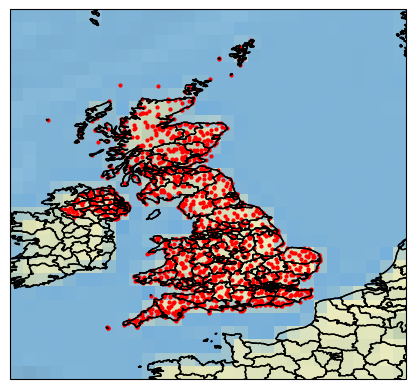

In [22]:
figure = matplotlib.pyplot.figure()

ax1 = figure.add_subplot(1,1,1, projection=cartopy.crs.PlateCarree())
ax1.add_feature(cartopy.feature.COASTLINE)
ax1.add_feature(cartopy.feature.STATES)

ax1.stock_img()
ax1.set_extent(
    [-10, 5, 48, 62],
    crs=cartopy.crs.PlateCarree()
)

ax1.scatter(
    x=hourly_weather_metadata_df["station_longitude"],
    y=hourly_weather_metadata_df["station_latitude"],
    color="red",
    s=4,
    alpha=1,
    transform=cartopy.crs.PlateCarree()
)

## Exploring a weather question
For the tutorial, we're going to try to use this dataset to answer a question about past weather. In particular consider whether the warm weather in May and June 2026 si unusal for Devon. There are various ways to consider. One way is simply to compare the mean  daily maximum temperature. That will tell us for the whole month, but there might have been some very cool days alongside warm days. Devon could have experienced some extemely warm days but the average may not fully show that. Instead we could look at the number of days wheere the max temp was above various thesholds. To start we'll find the stations in Devon.

In [25]:
hourly_weather_metadata_df[hourly_weather_metadata_df['historic_county'] == 'devon']

,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
src_id,,,,,,,,,
01331,VIRGINSTOW,virginstow,devon,Met Office,50.721,-4.288,168.0,1968.0,1973.0
01332,HARTLAND POINT,hartland-point,devon,Met Office,51.020,-4.524,95.0,1957.0,1983.0
01333,HARTLAND,hartland,devon,Met Office,50.991,-4.462,142.0,1983.0,1988.0
01334,GAWLISH,gawlish,devon,Met Office,51.016,-4.490,122.0,1989.0,2003.0
01335,LUNDY,lundy,devon,Met Office,51.161,-4.656,43.0,1983.0,1994.0
...,...,...,...,...,...,...,...,...,...
62041,EXETER AIRPORT NO 2,exeter-airport-no-2,devon,Met Office,50.737,-3.406,27.0,2009.0,2024.0
62200,"HOLNE, PRIDDONS FARM NO 2",holne-priddons-farm-no-2,devon,Met Office,50.517,-3.842,280.0,2019.0,2024.0
62208,EXETER SURFACENET ENCLOSURE AWS,exeter-surfacenet-enclosure-aws,devon,Met Office,50.729,-3.475,0.0,2020.0,2024.0


Lets look specifically at Exeter. Exeter shows one of the comlexities of this dataset, because there hasn't been a single weather station in the same place across the whole duration of observations.Likely something about the site changed, or the instruments were moved a short distance, breaking continuity. 

In [26]:
[s1 for s1 in station_list if 'exeter' in s1.lower()]

['EXETER SOUTHAM',
 'EXETER AIRPORT',
 'EXETER AIRPORT NO 2',
 'EXETER SURFACENET ENCLOSURE AWS']

In [27]:
hourly_weather_metadata_df[hourly_weather_metadata_df.apply(lambda row1: 'exeter' in row1['station_name'].lower(), axis='columns')]

,station_name,station_file_name,historic_county,authority,station_latitude,station_longitude,station_elevation,first_year,last_year
src_id,,,,,,,,,
01374,EXETER SOUTHAM,exeter-southam,devon,Met Office,50.718,-3.487,46.0,1972.0,1972.0
01378,EXETER AIRPORT,exeter-airport,devon,Met Office,50.731,-3.417,27.0,1968.0,1991.0
62041,EXETER AIRPORT NO 2,exeter-airport-no-2,devon,Met Office,50.737,-3.406,27.0,2009.0,2024.0
62208,EXETER SURFACENET ENCLOSURE AWS,exeter-surfacenet-enclosure-aws,devon,Met Office,50.729,-3.475,0.0,2020.0,2024.0


To make thigs easier, we could look at devon staions with recent observations (datasr only goes to 2024 so far)

In [29]:
hourly_weather_metadata_df[(hourly_weather_metadata_df['historic_county'] =='devon') & (hourly_weather_metadata_df['last_year'] > 2023) ][['station_file_name', 'first_year','last_year']]

,station_file_name,first_year,last_year
src_id,,,
01336,plymouth-mountbatten,1949.0,2024.0
01345,okehampton-east-okement-farm,1992.0,2024.0
01346,chivenor,1957.0,2024.0
01352,north-wyke,1981.0,2024.0
01362,slapton,1972.0,2024.0
01367,berry-head,2000.0,2024.0
01371,teignmouth,1910.0,2024.0
01382,hemyock,1978.0,2024.0
01383,dunkeswell-aerodrome,1986.0,2024.0


We can select a station with a long record near to Exeter, such as Dunkeswell Aerodrome.

In [30]:
selected_id = 1383

### Load station data
Now that we have selected a station, we can build the path to the data files. The data is divided into files by year, so we will need to load in all the years and concatenate into a single  dataframe.

In [33]:
selected_station_fname = hourly_weather_metadata_df.loc[f'{selected_id:05d}']['station_file_name']
selected_county =  hourly_weather_metadata_df.loc[f'{selected_id:05d}']['historic_county']
selected_version_long = 'qc-version-1'
selected_version_short = 'qcv-1'
selected_station_fname, selected_county, selected_version_long
selected_station_range = ( int(hourly_weather_metadata_df.loc[f'{selected_id:05d}']['first_year']), int(hourly_weather_metadata_df.loc[f'{selected_id:05d}']['last_year']) )


In [34]:
selected_station_fname, selected_county, selected_station_range

('dunkeswell-aerodrome', 'devon', (1986, 2024))

In [36]:
selected_station_dir = hourly_weather_dir / selected_county / f'{selected_id:05d}_{selected_station_fname}' / selected_version_long
selected_station_dir

PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507/devon/01383_dunkeswell-aerodrome/qc-version-1')

In [37]:
sorted(list(selected_station_dir.iterdir()))

[PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507/devon/01383_dunkeswell-aerodrome/qc-version-1/midas-open_uk-hourly-weather-obs_dv-202507_devon_01383_dunkeswell-aerodrome_qcv-1_1986.csv'),
 PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507/devon/01383_dunkeswell-aerodrome/qc-version-1/midas-open_uk-hourly-weather-obs_dv-202507_devon_01383_dunkeswell-aerodrome_qcv-1_1987.csv'),
 PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507/devon/01383_dunkeswell-aerodrome/qc-version-1/midas-open_uk-hourly-weather-obs_dv-202507_devon_01383_dunkeswell-aerodrome_qcv-1_1988.csv'),
 PosixPath('/data/users/haduk/uk_climate_data/supported/midas-open/v202507/data/uk-hourly-weather-obs/dataset-version-202507/devon/01383_dunkeswell-aerodrome/qc-version-1/midas-open_uk-hourly-weather-obs_d

In [43]:
data_fname_template = '{ds_name}_dv-{ds_version}_{county}_{station_id}_{station_name}_{qcv}_{year:04d}.csv'

In [44]:
station_path_list = {current_year: selected_station_dir / data_fname_template.format(ds_name=dataset_name,
                                                                            ds_version=dataset_version,
                                                                            county=selected_county,
                                                                            station_id=f'{selected_id:05}',
                                                                            station_name=selected_station_fname,
                                                                            qcv=selected_version_short,
                                                                            year=current_year,
                                                                           )
                    for current_year in range(selected_station_range[0], selected_station_range[1] +1)}

In [45]:
station_df = pandas.concat([pandas.read_csv(p1, skiprows=283) for p1 in station_path_list.values()])

/var/tmp/ipykernel_1421784/3616207284.py:1: DtypeWarning: Columns (93) have mixed types. Specify dtype option on import or set low_memory=False.
  station_df = pandas.concat([pandas.read_csv(p1, skiprows=283) for p1 in station_path_list.values()])
/var/tmp/ipykernel_1421784/3616207284.py:1: DtypeWarning: Columns (93) have mixed types. Specify dtype option on import or set low_memory=False.
  station_df = pandas.concat([pandas.read_csv(p1, skiprows=283) for p1 in station_path_list.values()])
/var/tmp/ipykernel_1421784/3616207284.py:1: DtypeWarning: Columns (93) have mixed types. Specify dtype option on import or set low_memory=False.
  station_df = pandas.concat([pandas.read_csv(p1, skiprows=283) for p1 in station_path_list.values()])
/var/tmp/ipykernel_1421784/3616207284.py:1: DtypeWarning: Columns (88,89) have mixed types. Specify dtype option on import or set low_memory=False.
  station_df = pandas.concat([pandas.read_csv(p1, skiprows=283) for p1 in station_path_list.values()])
/var/

### Clean the data
Having loaded the files, we also want to clean the data, such as removing NaNs, converting datetime string into datetime objects and other useful operations, such as providing a day field. This removes the time aspect, so we can group observation by day to calculate the max temp each day.

In [46]:
station_df = station_df[~station_df['id'].isna()]
    

In [47]:
station_df['ob_time'] = pandas.to_datetime(station_df['ob_time'])

In [48]:
station_df['day'] = station_df['ob_time'].apply(lambda dt: datetime.datetime(dt.year,dt.month,dt.day,0,0))

In [49]:
station_df

,ob_time,id,id_type,met_domain_name,version_num,src_id,rec_st_ind,wind_speed_unit_id,src_opr_type,wind_direction,...,rltv_hum_j,vert_vsby_j,stn_pres_j,alt_pres_j,q10mnt_mxgst_spd_j,meto_stmp_time,midas_stmp_etime,drv_hr_sun_dur,drv_hr_sun_dur_q,day
0,1986-11-01 09:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,270.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1986-11-01
1,1986-11-01 12:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,320.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1986-11-01
2,1986-11-01 15:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,360.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1986-11-01
3,1986-11-02 09:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,320.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1986-11-02
4,1986-11-02 12:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,90.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1986-11-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8701,2024-12-31 19:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,6.0,220.0,...,NaN,NaN,NaN,NaN,NaN,2024-12-31 19:01:13,NaN,NaN,NaN,2024-12-31
8702,2024-12-31 20:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,230.0,...,NaN,NaN,NaN,NaN,NaN,2024-12-31 20:01:16,NaN,NaN,NaN,2024-12-31
8703,2024-12-31 21:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,230.0,...,NaN,NaN,NaN,NaN,NaN,2024-12-31 21:02:12,NaN,NaN,NaN,2024-12-31
8704,2024-12-31 22:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,230.0,...,NaN,NaN,NaN,NaN,NaN,2024-12-31 22:01:12,NaN,NaN,NaN,2024-12-31


### Select subset
For this analysis, we are interested in the months of May and June, so we will select a subset of the data.

In [52]:
station_df = station_df[station_df['ob_time'].apply(lambda dt: dt.month >=5 and dt.month <=6)]
station_df

,ob_time,id,id_type,met_domain_name,version_num,src_id,rec_st_ind,wind_speed_unit_id,src_opr_type,wind_direction,...,rltv_hum_j,vert_vsby_j,stn_pres_j,alt_pres_j,q10mnt_mxgst_spd_j,meto_stmp_time,midas_stmp_etime,drv_hr_sun_dur,drv_hr_sun_dur_q,day
359,1987-05-01 09:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,230.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987-05-01
360,1987-05-01 12:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,230.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987-05-01
361,1987-05-01 15:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,320.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987-05-01
362,1987-05-02 09:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,320.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987-05-02
363,1987-05-02 12:00:00,3841.0,WMO,SYNOP,1.0,1383.0,1011.0,NaN,NaN,320.0,...,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1987-05-02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4319,2024-06-30 19:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,310.0,...,NaN,NaN,NaN,NaN,NaN,2024-06-30 19:01:11,NaN,NaN,NaN,2024-06-30
4320,2024-06-30 20:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,320.0,...,NaN,NaN,NaN,NaN,NaN,2024-06-30 20:01:44,NaN,NaN,NaN,2024-06-30
4321,2024-06-30 21:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,310.0,...,NaN,NaN,NaN,NaN,NaN,2024-06-30 21:02:12,NaN,NaN,NaN,2024-06-30
4322,2024-06-30 22:00:00,3840.0,WMO,SYNOP,1.0,1383.0,1011.0,4.0,5.0,300.0,...,NaN,NaN,NaN,NaN,NaN,2024-06-30 22:01:07,NaN,NaN,NaN,2024-06-30


In [ ]:
temp_threshold = 25

First we calculate daily maximum temperatures using the [**groupby** functionality](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) in pandas. This takes all observations for a given day and performs a specific operation on that group, and does that for all groups. Here for each day, we will find the max temp. 

In [53]:
max_temp_daily = station_df.groupby(['day'])['air_temperature'].max() 

Now we will create a new dataframe, which looks at each day in the dataset and finds the max temp and whether it exceeds certain thresholds, so we can count the number of days and plot.

In [54]:
max_temp_daily_df = pandas.DataFrame( {'date': pandas.Series(max_temp_daily.index), 
                                       'year': pandas.Series(max_temp_daily.index).apply(lambda dt: dt.year), 
                                       'daily_max_temp': max_temp_daily.values, 
                                       'daily_max_exceeds_25': [int(v1> 25) for v1 in max_temp_daily.values],
                                       'daily_max_exceeds_27': [int(v1> 27) for v1 in max_temp_daily.values],
                                       'daily_max_exceeds_29': [int(v1> 29) for v1 in max_temp_daily.values],
                                       'daily_max_exceeds_30': [int(v1> 30) for v1 in max_temp_daily.values],
                                      })

In [55]:
max_temp_daily_df

,date,year,daily_max_temp,daily_max_exceeds_25,daily_max_exceeds_27,daily_max_exceeds_29,daily_max_exceeds_30
0,1987-05-01,1987,11.5,0,0,0,0
1,1987-05-02,1987,9.2,0,0,0,0
2,1987-05-03,1987,9.8,0,0,0,0
3,1987-05-04,1987,7.1,0,0,0,0
4,1987-05-05,1987,11.5,0,0,0,0
...,...,...,...,...,...,...,...
2295,2024-06-26,2024,25.0,0,0,0,0
2296,2024-06-27,2024,18.7,0,0,0,0
2297,2024-06-28,2024,17.8,0,0,0,0
2298,2024-06-29,2024,20.7,0,0,0,0


<Axes: xlabel='year'>

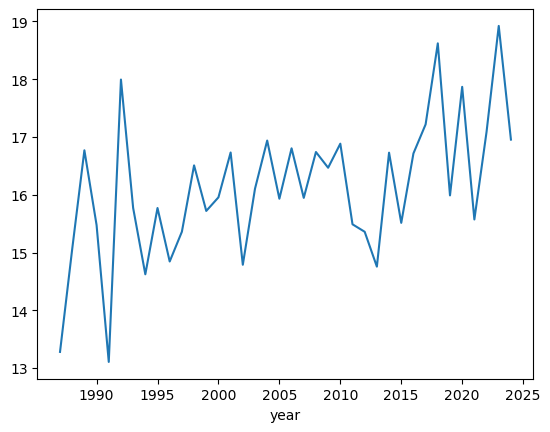

We can now compare what the mean max daily temp by year shows us compared to the number of days above a certain threshold.

<Axes: title={'center': 'mean and exceeded counts'}, xlabel='year'>

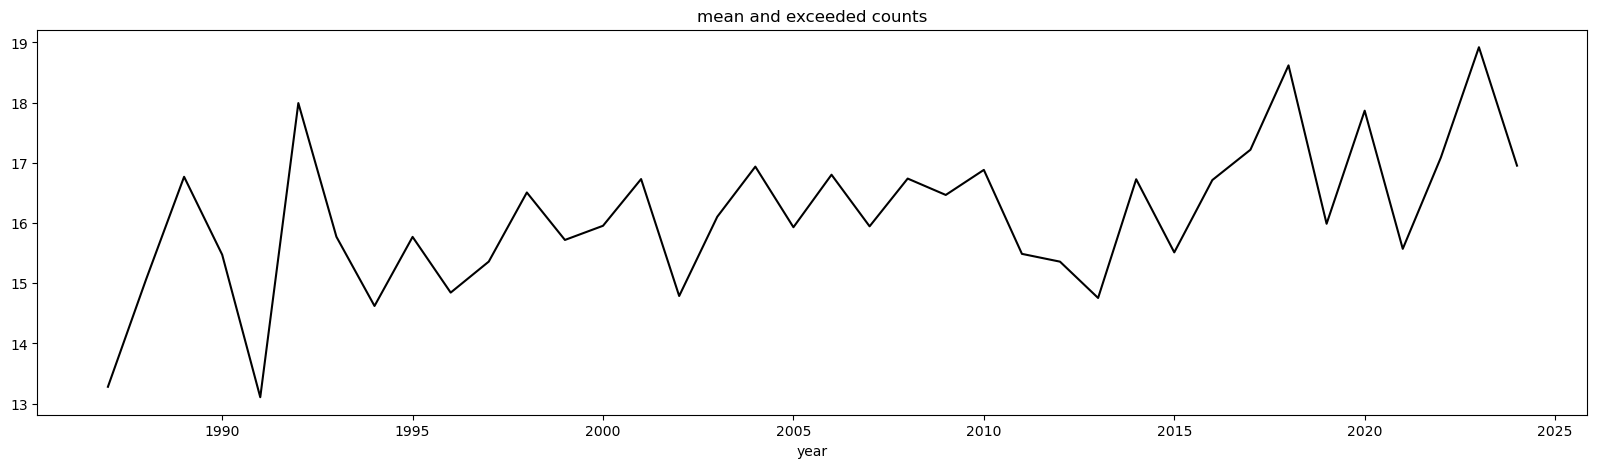

In [65]:
fig1 = matplotlib.pyplot.figure(figsize=(20,5))
ax1 = fig1.add_subplot(1,1,1, title='mean and exceeded counts')
max_temp_daily_df.groupby(['year'])['daily_max_temp'].mean().plot(ax=ax1,c='k')


<Axes: title={'center': 'mean and exceeded counts'}, xlabel='year'>

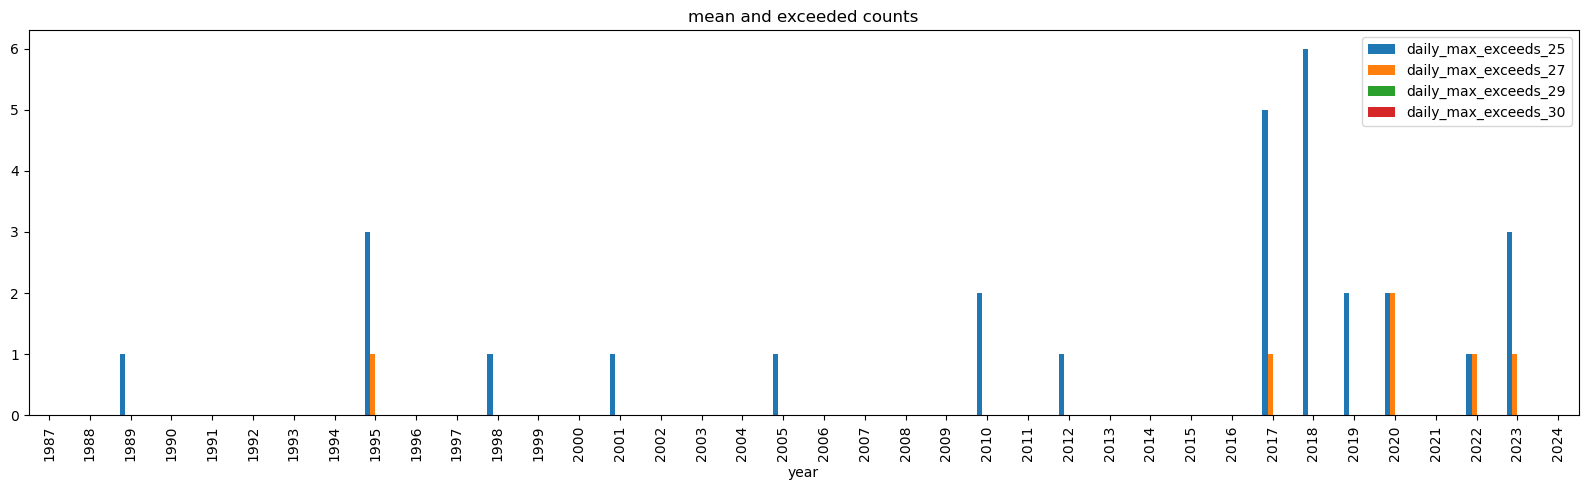

In [66]:
fig1 = matplotlib.pyplot.figure(figsize=(20,5))
ax1 = fig1.add_subplot(1,1,1, title='mean and exceeded counts')
max_temp_daily_df.groupby(['year'])[['daily_max_exceeds_25', 'daily_max_exceeds_27',  'daily_max_exceeds_29', 'daily_max_exceeds_30']].sum().plot.bar(ax=ax1)


### Further Reading

* Weather Station Data
  * [Weather Stations - Met Office](https://weather.metoffice.gov.uk/learn-about/how-forecasts-are-made/observations/weather-stations)
  * [Weather Stations - Wikipedia](https://en.wikipedia.org/wiki/Weather_station)
  * [MIDAS dataset]()
  * [MIDAS Open dataset](https://catalogue.ceda.ac.uk/uuid/dbd451271eb04662beade68da43546e1/)
  * [HadISD](https://www.metoffice.gov.uk/hadobs/hadisd/) - Similar dataset for weather stations around the world
* Tabular Data
  * [Pandas Library](https://pandas.pydata.org/docs/)
  * [Intro to tabular data](https://pandas.pydata.org/docs/getting_started/intro_tutorials/02_read_write.html )